# Pakage export

In [2]:
import os
import shap
import kagglehub
import pandas as pd
import numpy as np
from scipy.stats import mstats
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from imblearn.over_sampling import SMOTE
from sklearn.compose import ColumnTransformer
import seaborn as sns, matplotlib.pyplot as plt
from imblearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler, OrdinalEncoder
from lightgbm import LGBMClassifier
import optuna
from xgboost import XGBClassifier
from catboost import CatBoostClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.calibration import CalibratedClassifierCV
from sklearn.ensemble import RandomForestClassifier, StackingClassifier
from sklearn.model_selection import (train_test_split, StratifiedKFold, cross_val_score)

<h1>Data Export</h1>

In [3]:
kagglehub.login()

In [4]:
# Download latest version
path = kagglehub.competition_download('playground-series-s6e5')
print("Path to competition files:", path)

Path to competition files: C:\Users\koust\.cache\kagglehub\competitions\playground-series-s6e5


In [5]:
print(os.listdir(path))  # see files

train = pd.read_csv(os.path.join(path, "train.csv"))
test = pd.read_csv(os.path.join(path, "test.csv"))

['sample_submission.csv', 'test.csv', 'train.csv']


<h1>Split Data</h1>

In [6]:
display(train.head())
display(test.head())

,id,Driver,Compound,Race,Year,PitStop,LapNumber,Stint,TyreLife,Position,LapTime (s),LapTime_Delta,Cumulative_Degradation,RaceProgress,Position_Change,PitNextLap
0,0,D109,HARD,Canadian Grand Prix,2022,0,50,2,39.0,8,78.491,-7.564,21.019,0.714286,5.0,1.0
1,1,D086,HARD,Dutch Grand Prix,2025,1,27,2,7.0,4,75.095,-32.617,-223.207,0.346154,-3.0,0.0
2,2,ZON,HARD,Austrian Grand Prix,2022,0,59,3,22.0,13,70.945,-7.540,-100.529,0.819444,3.0,1.0
3,3,SPE,MEDIUM,Pre-Season Testing,2023,0,2,1,2.0,7,94.361,-7.324,-7.324,0.076923,0.0,0.0
4,4,D019,HARD,Azerbaijan Grand Prix,2022,1,26,3,6.0,2,107.878,8.965,-14.139,0.361111,3.0,0.0


,id,Driver,Compound,Race,Year,PitStop,LapNumber,Stint,TyreLife,Position,LapTime (s),LapTime_Delta,Cumulative_Degradation,RaceProgress,Position_Change
0,439140,D119,MEDIUM,British Grand Prix,2023,0,21,1,21.0,4,93.387,0.280,-4.984,0.403846,0.0
1,439141,VER,MEDIUM,Abu Dhabi Grand Prix,2023,0,24,1,24.0,1,90.867,-0.129,-1.990,0.413793,0.0
2,439142,D270,MEDIUM,British Grand Prix,2023,0,24,1,24.0,11,92.871,0.041,-8.842,0.461538,0.0
3,439143,D112,SOFT,São Paulo Grand Prix,2024,0,6,2,4.0,15,94.967,-19.741,8.250,0.077922,1.0
4,439144,AND,HARD,United States Grand Prix,2024,0,52,2,29.0,12,99.112,0.930,-20.848,0.722222,7.0


In [7]:
X = train.drop(columns=['id','PitNextLap'])
y = train['PitNextLap']
X_temp, X_test, y_temp, y_test = train_test_split(
    X, y, test_size=0.15, stratify=y, random_state=42)
X_train, X_val, y_train, y_val = train_test_split(
    X_temp, y_temp, test_size=0.176, stratify=y_temp, random_state=42)

In [8]:
display(X_train.shape, X_test.shape, X_val.shape)

(307573, 14)

(65871, 14)

(65696, 14)

<h1>EDA</h1>

In [9]:
display(X_train.head())

,Driver,Compound,Race,Year,PitStop,LapNumber,Stint,TyreLife,Position,LapTime (s),LapTime_Delta,Cumulative_Degradation,RaceProgress,Position_Change
265268,TUR,INTERMEDIATE,Monaco Grand Prix,2023,0,69,3,20.0,4,93.974,0.000,0.000,0.884615,0.0
102155,D064,MEDIUM,Japanese Grand Prix,2023,0,17,1,17.0,5,99.876,-0.001,-0.001,0.320755,0.0
51941,D074,HARD,Australian Grand Prix,2023,0,42,2,34.0,9,84.292,0.263,-8.654,0.724138,0.0
35710,NOR,MEDIUM,British Grand Prix,2023,0,11,1,13.0,2,91.360,-0.236,-3.573,0.211538,0.0
289760,FIT,HARD,Australian Grand Prix,2022,0,45,3,32.0,18,85.000,-9.600,-42.957,0.633803,-2.0


In [10]:
display(X_train['Driver'].nunique())
display(X_train['Race'].nunique())

853

26

#### Is there any duplicate values?

In [11]:
print(X_train.duplicated().sum())

0


#### Shape & types

In [12]:
X_train.shape

(307573, 14)

In [13]:
X_train.dtypes

Driver                        str
Compound                      str
Race                          str
Year                        int64
PitStop                     int64
LapNumber                   int64
Stint                       int64
TyreLife                  float64
Position                    int64
LapTime (s)               float64
LapTime_Delta             float64
Cumulative_Degradation    float64
RaceProgress              float64
Position_Change           float64
dtype: object

In [14]:
X_train.dtypes.value_counts()

float64    6
int64      5
str        3
Name: count, dtype: int64

#### Missing value

In [15]:
X_train.isnull().sum()

Driver                    0
Compound                  0
Race                      0
Year                      0
PitStop                   0
LapNumber                 0
Stint                     0
TyreLife                  0
Position                  0
LapTime (s)               0
LapTime_Delta             0
Cumulative_Degradation    0
RaceProgress              0
Position_Change           0
dtype: int64

In [16]:
X_train.isnull().sum()[X_train.isnull().sum() > 0]

Series([], dtype: int64)

#### Class balance

In [17]:
y_train.value_counts(normalize=True)

PitNextLap
0.0    0.801016
1.0    0.198984
Name: proportion, dtype: float64

#### Correlations

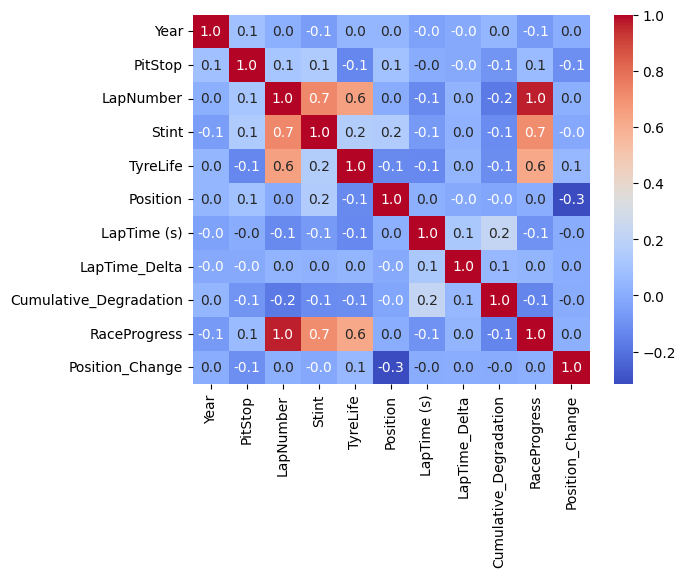

In [18]:
sns.heatmap(X_train.select_dtypes("number").corr(),
            annot=True, fmt= ".1f", cmap="coolwarm")  # anoot true show data inside the those boxs and fmt how many value did you want to show after point
plt.show()

#### Outliers

In [19]:
num_cols = X_train.select_dtypes(include=["number"]).columns
num_cols

Index(['Year', 'PitStop', 'LapNumber', 'Stint', 'TyreLife', 'Position',
       'LapTime (s)', 'LapTime_Delta', 'Cumulative_Degradation',
       'RaceProgress', 'Position_Change'],
      dtype='str')

In [20]:
for col in num_cols:
    Q1 = X_train[col].quantile(0.25)
    Q3 = X_train[col].quantile(0.75)
    IQR = Q3 - Q1
    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR
    outlier_mask = (X_train[col] < lower) | (X_train[col] > upper)
    print(col, "outliers:", outlier_mask.sum())

Year outliers: 0
PitStop outliers: 41833
LapNumber outliers: 11
Stint outliers: 16867
TyreLife outliers: 4013
Position outliers: 0
LapTime (s) outliers: 4122
LapTime_Delta outliers: 41109
Cumulative_Degradation outliers: 34997
RaceProgress outliers: 0
Position_Change outliers: 42914


In [21]:
col_dic = {}

for col in num_cols:
    col_dic[col] = X_train[col].unique()
for col, values in col_dic.items():
    print(col, ":", values)

Year : [2023 2022 2025 2024]
PitStop : [0 1]
LapNumber : [69 17 42 11 45  7 21 36 50 63 39 44  5 19  8  1 43 27 14 15  6 26 25 49
 20 31 38  9 66 12 51 52  3 40 55 60 18  4 29 33 53 16 13  2 61 24 37 10
 64 23 56 22 54 35 30 47 58 57 34 62 28 48 32 41 68 65 46 59 72 70 67 74
 71 75 77 76 73 78]
Stint : [3 1 2 4 5 6 8 7]
TyreLife : [20.  17.  34.  13.  32.   7.   6.  11.  57.  27.  26.   5.  21.   2.
 19.   8.   1.   9.  31.  14.  15.  23.  25.   4.  48.  12.   3.  22.
 18.  39.  24.  29.  16.  60.  10.  49.  42.  33.  30.  40.  35.  28.
 43.  36.  38.  41.  37.  53.  46.  54.  72.  47.  44.  62.  45.  69.
 66.  55.  50.  59.  58.  56.  64.  65.  70.  71.  67.  52.  61.  51.
 63.  75.  76.  74.  68.  73.  60.5 77. ]
Position : [ 4  5  9  2 18 15 13 11  3  8 12 14  7  6 17 19 16 10  1 20]
LapTime (s) : [93.974 99.876 84.292 ... 70.303 89.51  72.212]
LapTime_Delta : [ 0.0000e+00 -1.0000e-03  2.6300e-01 ... -3.4964e+01 -1.3736e+01
 -6.0390e+00]
Cumulative_Degradation : [ 0.00000e+00 -1.000

# Data Cleaning (Fixing problem which are found in EDA process)


### **Problem**
    1. Highly imbalanced (1 ~ 20%, 0 ~ 80%)
    2. Outliers
    3. Correlated columns

#### ***1. Highly imbalanced (1 ~ 20%, 0 ~ 80%)*** -> **Which I did in Pipeline Section**

#### ***2. Outliers***

In [22]:
skip_cols = ["PitStop", "Position_Change", "Year",
             "LapNumber", "Position", "RaceProgress"]

winsorize_cols = ["Stint", "TyreLife", "LapTime_Delta",
                  "Cumulative_Degradation"]

flag_and_cap_cols = ["LapTime (s)"]

cap_map = {}  # stores {col: (lower, upper)} from training data

# Winsorize
for col in winsorize_cols:
    lo = X_train[col].quantile(0.01)
    hi = X_train[col].quantile(0.99)
    cap_map[col] = (lo, hi)
    X_train[col] = X_train[col].clip(lower=lo, upper=hi)
    print(f"[{col}] Clipped to [{lo:.2f}, {hi:.2f}]")

# Flag + Winsorize for LapTime (s) — safety car laps are useful signal
for col in flag_and_cap_cols:
    lo = X_train[col].quantile(0.01)
    hi = X_train[col].quantile(0.99)
    cap_map[col] = (lo, hi)
    X_train[f"is_extreme_{col.replace(' ','_')}"] = (
        (X_train[col] < lo) | (X_train[col] > hi)
    ).astype(int)
    X_train[col] = X_train[col].clip(lower=lo, upper=hi)
    print(f"[{col}] Flagged extremes + clipped to [{lo:.2f}, {hi:.2f}]")

# ── Apply the SAME stored caps to val and test (never refit on them)
for col, (lo, hi) in cap_map.items():
    X_val[col]  = X_val[col].clip(lower=lo, upper=hi)
    X_test[col] = X_test[col].clip(lower=lo, upper=hi)

# Copy the flag column to val and test too
for col in flag_and_cap_cols:
    flag_name = f"is_extreme_{col.replace(' ','_')}"
    lo, hi = cap_map[col]
    X_val[flag_name]  = ((X_val[col] < lo) | (X_val[col] > hi)).astype(int)
    X_test[flag_name] = ((X_test[col] < lo) | (X_test[col] > hi)).astype(int)

print("\nDone. Columns left untouched:", skip_cols)

[Stint] Clipped to [1.00, 5.00]
[TyreLife] Clipped to [1.00, 43.00]
[LapTime_Delta] Clipped to [-40.19, 30.98]
[Cumulative_Degradation] Clipped to [-205.01, 122.06]
[LapTime (s)] Flagged extremes + clipped to [70.72, 124.85]

Done. Columns left untouched: ['PitStop', 'Position_Change', 'Year', 'LapNumber', 'Position', 'RaceProgress']


In [23]:
display(X_train.head())
display(X_train.shape)

,Driver,Compound,Race,Year,PitStop,LapNumber,Stint,TyreLife,Position,LapTime (s),LapTime_Delta,Cumulative_Degradation,RaceProgress,Position_Change,is_extreme_LapTime_(s)
265268,TUR,INTERMEDIATE,Monaco Grand Prix,2023,0,69,3,20.0,4,93.974,0.000,0.000,0.884615,0.0,0
102155,D064,MEDIUM,Japanese Grand Prix,2023,0,17,1,17.0,5,99.876,-0.001,-0.001,0.320755,0.0,0
51941,D074,HARD,Australian Grand Prix,2023,0,42,2,34.0,9,84.292,0.263,-8.654,0.724138,0.0,0
35710,NOR,MEDIUM,British Grand Prix,2023,0,11,1,13.0,2,91.360,-0.236,-3.573,0.211538,0.0,0
289760,FIT,HARD,Australian Grand Prix,2022,0,45,3,32.0,18,85.000,-9.600,-42.957,0.633803,-2.0,0


(307573, 15)

#### ***3. Correlated Columns***
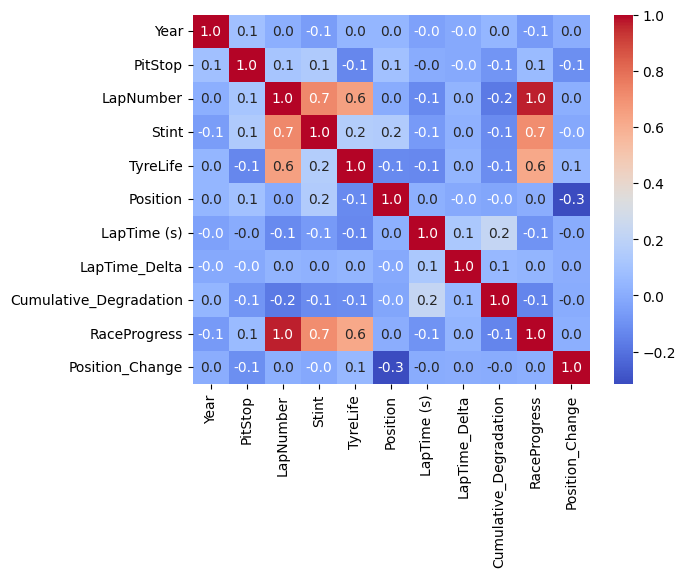

**From above I understand LapNumber and RaceProgress have 1 and one of them I drop and I ignored the values consiste of 0.6 or 0.7**

In [24]:
to_drop = ["LapNumber","is_extreme_LapTime_(s)","Driver"]  # drop original LapNumber + flag for extreme LapTime (s) since it was not helpful
X_train = X_train.drop(columns=to_drop)
X_val   = X_val.drop(columns=to_drop)
X_test  = X_test.drop(columns=to_drop)

print("Dropped:", to_drop)
print("Remaining features:", X_train.columns.tolist())


Dropped: ['LapNumber', 'is_extreme_LapTime_(s)', 'Driver']
Remaining features: ['Compound', 'Race', 'Year', 'PitStop', 'Stint', 'TyreLife', 'Position', 'LapTime (s)', 'LapTime_Delta', 'Cumulative_Degradation', 'RaceProgress', 'Position_Change']


In [25]:
X_train.dtypes

Compound                      str
Race                          str
Year                        int64
PitStop                     int64
Stint                       int64
TyreLife                  float64
Position                    int64
LapTime (s)               float64
LapTime_Delta             float64
Cumulative_Degradation    float64
RaceProgress              float64
Position_Change           float64
dtype: object

# Feature Engineering

In [26]:
def engineer_features(df):
    df = df.copy()

    # Deg per lap
    # df["Deg_Per_Lap"] = df["Cumulative_Degradation"] / (df["TyreLife"] + 1)

    # Tyre life as % of compound max
    compound_max_life = {
        "SOFT":20, "MEDIUM":32, "HARD":45, "INTERMEDIATE":30, "WET":25
    }
    df["TyreLife_Pct"] = df.apply(
        lambda r: r["TyreLife"] / compound_max_life.get(r["Compound"], 30),
        axis=1
    )

    # Tyre cliff flag
    # df["Is_Tyre_Cliff"] = (df["LapTime_Delta"] > 0.3).astype(int)

    # Race remaining
    df["RaceProgress_Remaining"] = 1 - df["RaceProgress"]

    # Stint × RaceProgress
    df["Stint_x_RaceProgress"] = df["Stint"] * df["RaceProgress"]

    # Compound risk score
    compound_risk = {"SOFT":3, "MEDIUM":2, "HARD":1, "INTERMEDIATE":2, "WET":2}
    df["Compound_Risk"] = df["Compound"].map(compound_risk).fillna(2)

    # Track type flags
    street = ["Monaco Grand Prix","Singapore Grand Prix","Azerbaijan Grand Prix"]
    high_d = ["British Grand Prix","Spanish Grand Prix","Bahrain Grand Prix"]
    df["Is_Street_Circuit"] = df["Race"].isin(street).astype(int)
    df["Is_High_Deg_Track"]  = df["Race"].isin(high_d).astype(int)

    return df

X_train = engineer_features(X_train)
X_val   = engineer_features(X_val)
X_test  = engineer_features(X_test)

print("New features added:")
new_cols = ["TyreLife_Pct","RaceProgress_Remaining","Stint_x_RaceProgress",
            "Compound_Risk","Is_Street_Circuit","Is_High_Deg_Track"]
print(X_train[new_cols].describe().round(3))

New features added:
       TyreLife_Pct  RaceProgress_Remaining  Stint_x_RaceProgress  \
count    307573.000              307573.000            307573.000   
mean          0.398                   0.662                 0.773   
std           0.265                   0.253                 0.870   
min           0.022                   0.000                 0.013   
25%           0.188                   0.487                 0.139   
50%           0.356                   0.731                 0.371   
75%           0.560                   0.870                 1.171   
max           2.150                   0.987                 5.000   

       Compound_Risk  Is_Street_Circuit  Is_High_Deg_Track  
count     307573.000         307573.000         307573.000  
mean           1.700              0.120              0.126  
std            0.622              0.325              0.332  
min            1.000              0.000              0.000  
25%            1.000              0.000              

**After use shap I see some are working better than other and some are irrelavent to the model so I droping those**

In [27]:
# Columns confirmed to drop based on SHAP
drop_cols = [
    "Is_Tyre_Cliff",          # near zero SHAP — no contribution
    "Deg_Per_Lap",            # near zero SHAP — redundant with TyreLife
    "RaceProgress",           # redundant — RaceProgress_Remaining is better
    "Compound",               # redundant — Compound_Risk encodes same info better
]

# Drop from all three splits
for df in [X_train, X_val, X_test]:
    existing = [c for c in drop_cols if c in df.columns]
    df.drop(columns=existing, inplace=True)

print("Dropped:", drop_cols)
print("Remaining features:", X_train.columns.tolist())

Dropped: ['Is_Tyre_Cliff', 'Deg_Per_Lap', 'RaceProgress', 'Compound']
Remaining features: ['Race', 'Year', 'PitStop', 'Stint', 'TyreLife', 'Position', 'LapTime (s)', 'LapTime_Delta', 'Cumulative_Degradation', 'Position_Change', 'TyreLife_Pct', 'RaceProgress_Remaining', 'Stint_x_RaceProgress', 'Compound_Risk', 'Is_Street_Circuit', 'Is_High_Deg_Track']


**Demo processing Pipeline**

In [28]:
num_cols = X_train.select_dtypes(include=["number"]).columns.tolist()
cat_cols = X_train.select_dtypes(include=["object","category"]).columns.tolist()


numeric_pipe = Pipeline([
  ("scale", StandardScaler()),
])
categorical_pipe = Pipeline([
  ("encode", OrdinalEncoder(handle_unknown="use_encoded_value", unknown_value=-1)),
])

transformers = [("num", numeric_pipe, num_cols)]
if cat_cols: transformers.append(("cat", categorical_pipe, cat_cols))
preprocessor = ColumnTransformer(transformers, remainder="drop")

# Check imbalance — use SMOTE only if needed
minority_ratio = y_train.value_counts(normalize=True).min()
use_smote = minority_ratio < 0.30

steps = [("pre", preprocessor)]
if use_smote: steps.append(("smote", SMOTE(random_state=42)))

C:\Users\koust\AppData\Local\Temp\ipykernel_29428\2590467647.py:2: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  cat_cols = X_train.select_dtypes(include=["object","category"]).columns.tolist()


**Build a demo random forest algo for testing about the feature**

CV Scores: [0.86357127 0.86401421 0.8596163  0.86161376 0.86209927]
Mean CV Accuracy: 0.8621829600498436
Interaction array detected — flattened to shape: (1000, 16)
SHAP values shape: (1000, 16)
Feature count: 16


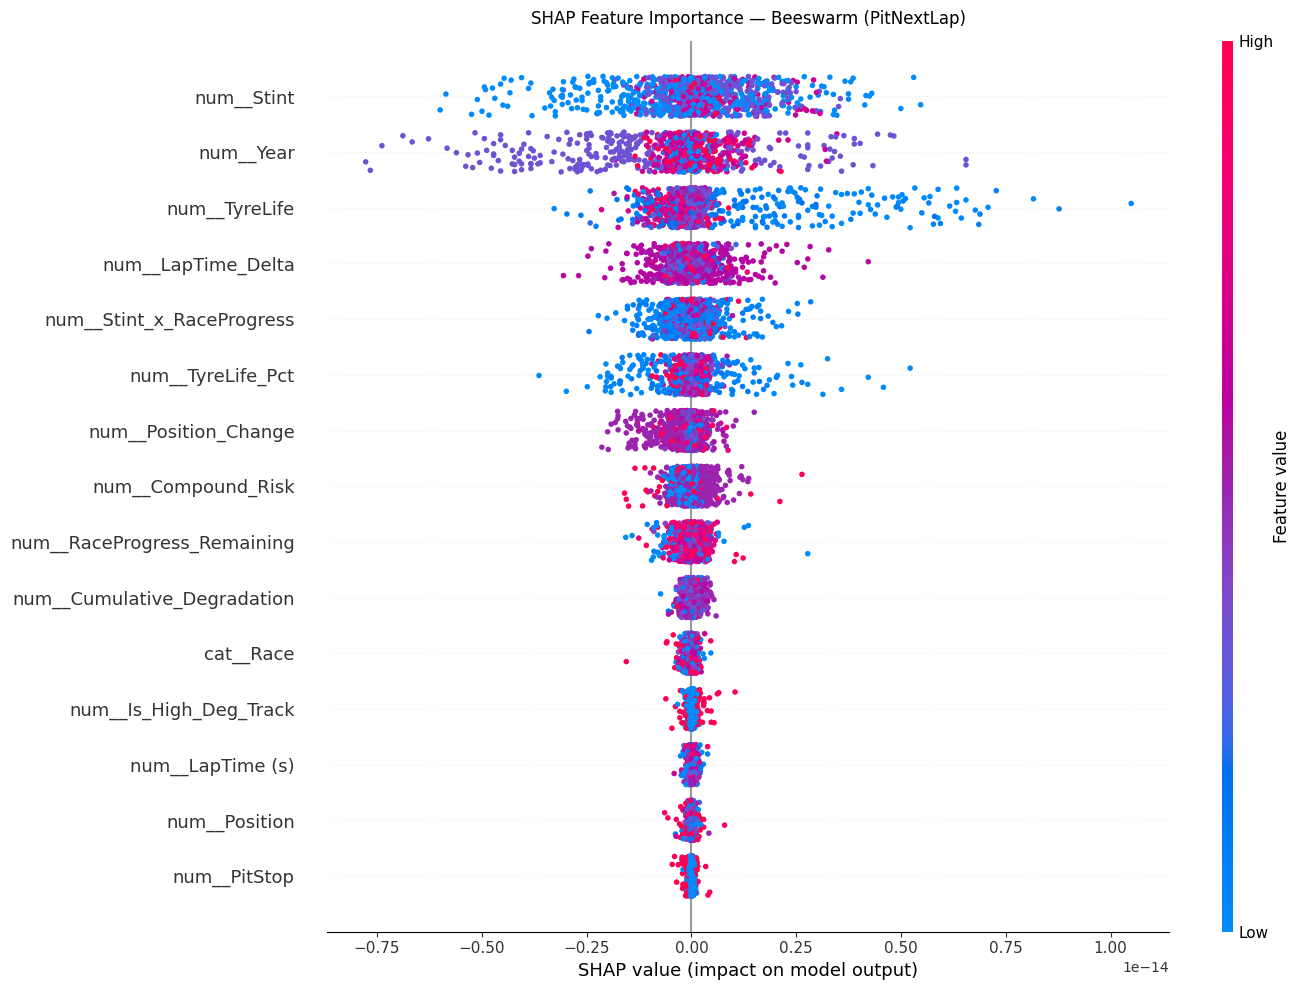

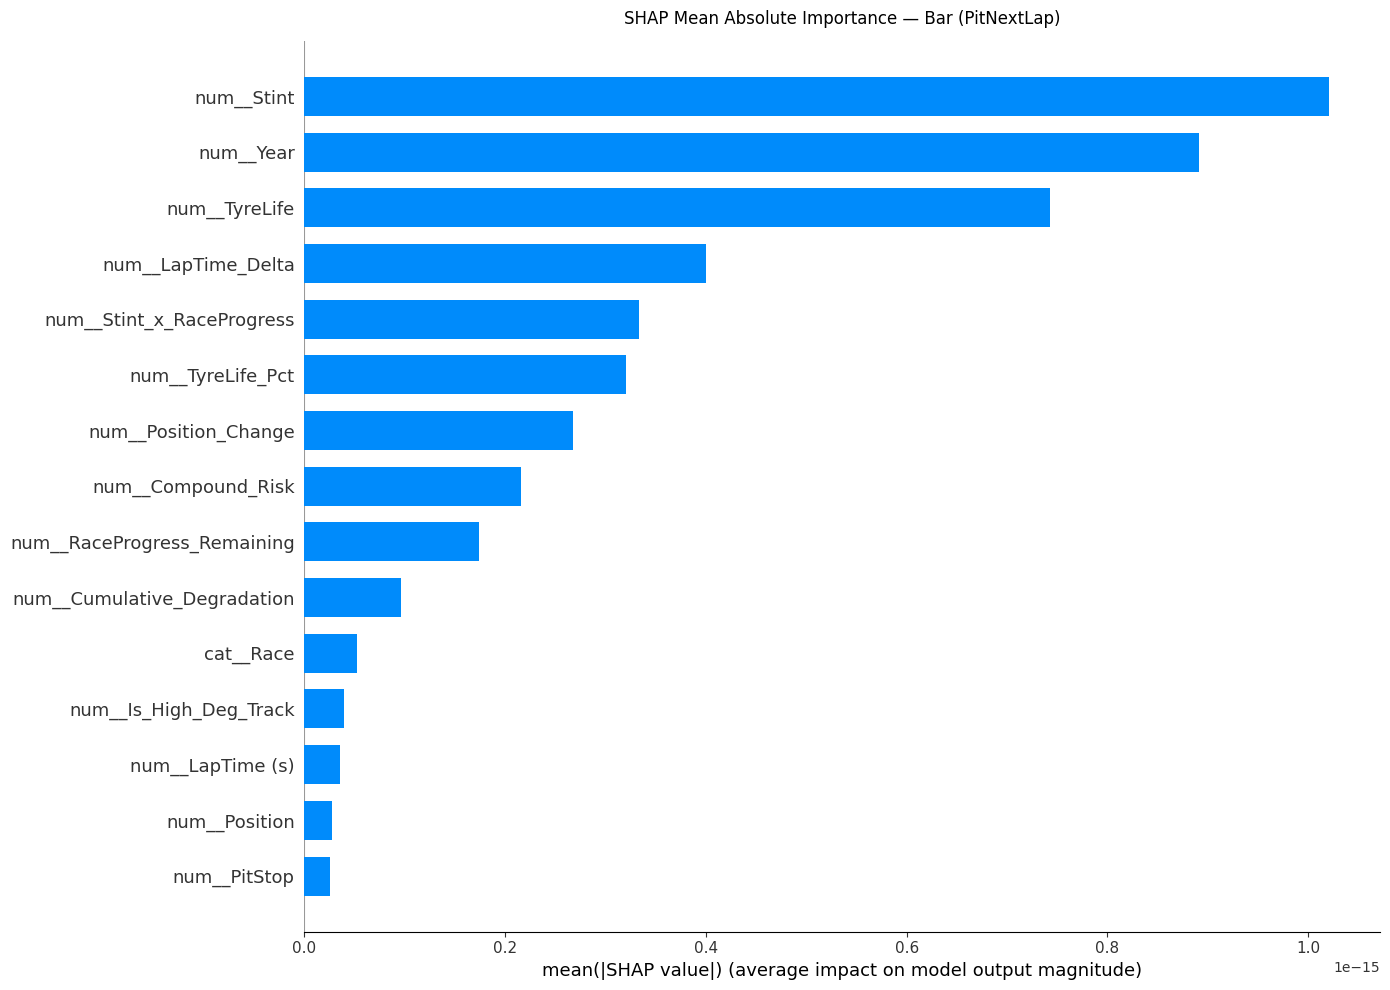

In [29]:
# Random Forest with some reasonable defaults + n_jobs for speed
rf = RandomForestClassifier(
    n_estimators=200,
    max_depth=10,
    random_state=42,
    n_jobs=-1
)

# Add model to pipeline
# steps.append(("clf", rf)) --- IGNORE ---


pipeline_steps = steps + [("clf", rf)]
pipeline = Pipeline(pipeline_steps)

# Cross-validation strategy
cv = StratifiedKFold(
    n_splits=5,
    shuffle=True,
    random_state=42
)

scores = cross_val_score(
    pipeline,
    X_train,
    y_train,
    cv=cv,
    scoring="balanced_accuracy",
    n_jobs=-1
)

print("CV Scores:", scores)
print("Mean CV Accuracy:", scores.mean())

# Fit pipeline
pipeline.fit(X_train, y_train)
rf_model = pipeline.named_steps["clf"]
pre = pipeline.named_steps["pre"]

# Transform + Sample
X_val_transformed = pre.transform(X_val)
feature_names     = pre.get_feature_names_out()
idx = np.random.choice(X_val_transformed.shape[0], 
                       size=1000,
                       replace=False)
X_sample = X_val_transformed[idx]  # adjust as needed based on dataset size and compute limits

# ── SHAP — FIX 1: force check_additivity=False ───────────
# Prevents TreeExplainer from trying to return interaction arrays
explainer   = shap.TreeExplainer(rf_model)
shap_values = explainer.shap_values(X_sample, check_additivity=False)

# ── FIX 2: always extract class-1 array cleanly ──────────
# shap_values is a list [class_0_array, class_1_array] for binary RF
# Each array shape should be (n_samples, n_features) — 2D
if isinstance(shap_values, list):
    sv = shap_values[1]   # class 1 = PitNextLap = True
else:
    sv = shap_values

# ── FIX 3: confirm shape is 2D before plotting ───────────
# If it's 3D (interaction matrix) — take the diagonal (self-interaction)
# which gives you a clean 2D importance array
if sv.ndim == 3:
    # Shape is (samples, features, features) — flatten to (samples, features)
    sv = sv[:, :, :].sum(axis=2)   # sum interactions per feature per sample
    print(f"Interaction array detected — flattened to shape: {sv.shape}")

print(f"SHAP values shape: {sv.shape}")
print(f"Feature count: {len(feature_names)}")

# ════════════════════════════════════════════════════════
# PLOT 1 — Beeswarm summary plot
# FIX 4: removed plt.figure() before shap call
#         SHAP creates its own figure internally
#         plt.figure() before it creates a blank orphan figure
# ════════════════════════════════════════════════════════
plt.close("all")                        # FIX 5: clear any leftover state

shap.summary_plot(
    sv,
    X_sample,
    feature_names=feature_names,
    max_display=15,                     # FIX 6: show top 15 features
    show=False                          # FIX 7: keep False so we control sizing
)

fig = plt.gcf()                         # FIX 8: get the figure SHAP just made
fig.set_size_inches(14, 10)            # resize it AFTER shap created it
plt.title("SHAP Feature Importance — Beeswarm (PitNextLap)", pad=12)
plt.tight_layout()
plt.show()
plt.close("all")                        # FIX 9: close before next plot

# ════════════════════════════════════════════════════════
# PLOT 2 — Bar chart
# ════════════════════════════════════════════════════════
shap.summary_plot(
    sv,
    X_sample,
    feature_names=feature_names,
    plot_type="bar",
    max_display=15,
    show=False
)

fig = plt.gcf()
fig.set_size_inches(14, 10)
plt.title("SHAP Mean Absolute Importance — Bar (PitNextLap)", pad=12)
plt.tight_layout()
plt.show()
plt.close("all")

```text
CV Scores: [0.85749884 0.85795173 0.85414275 0.85760787 0.85503304]
Mean CV Accuracy: 0.8564468464359865
Interaction array detected — flattened to shape: (1000, 14)
SHAP values shape: (1000, 14)
Feature count: 14
```
<!-- 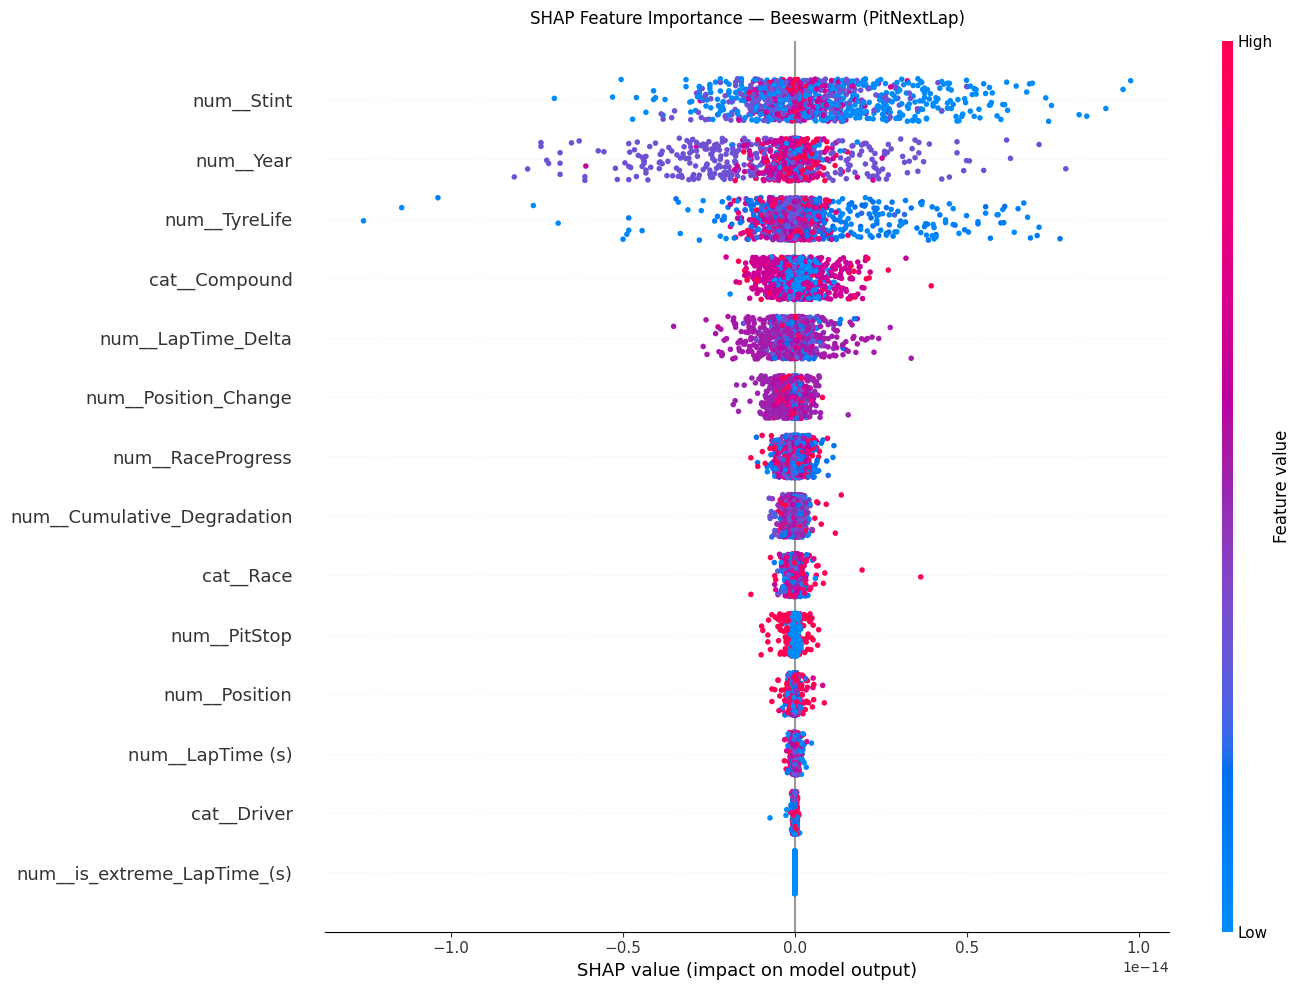
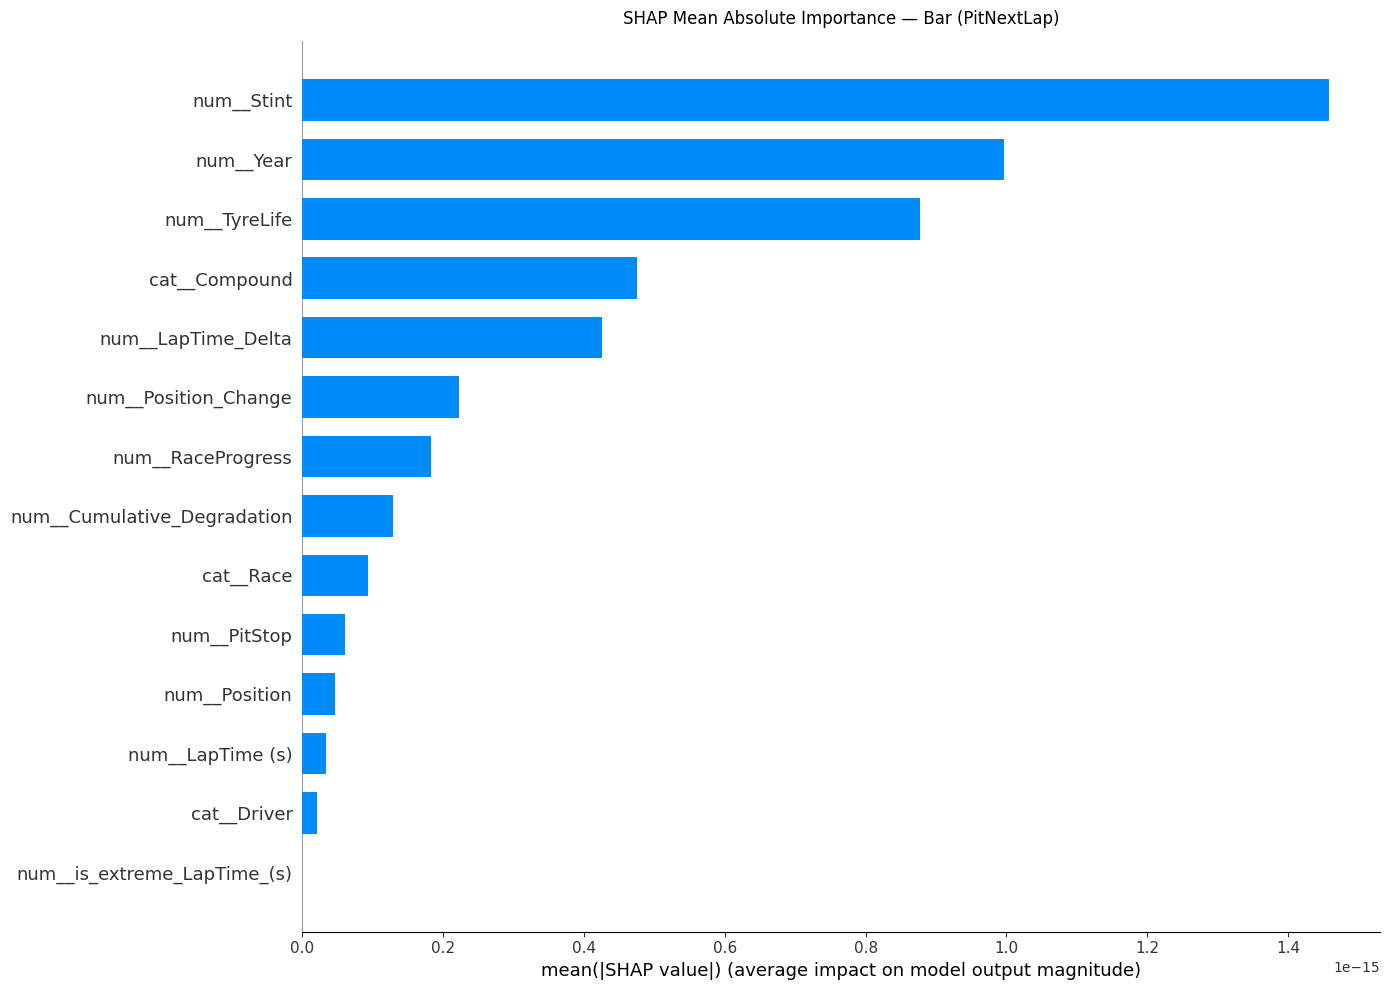 -->

| Image 1 | Image 2 |
| :---: | :---: |
| 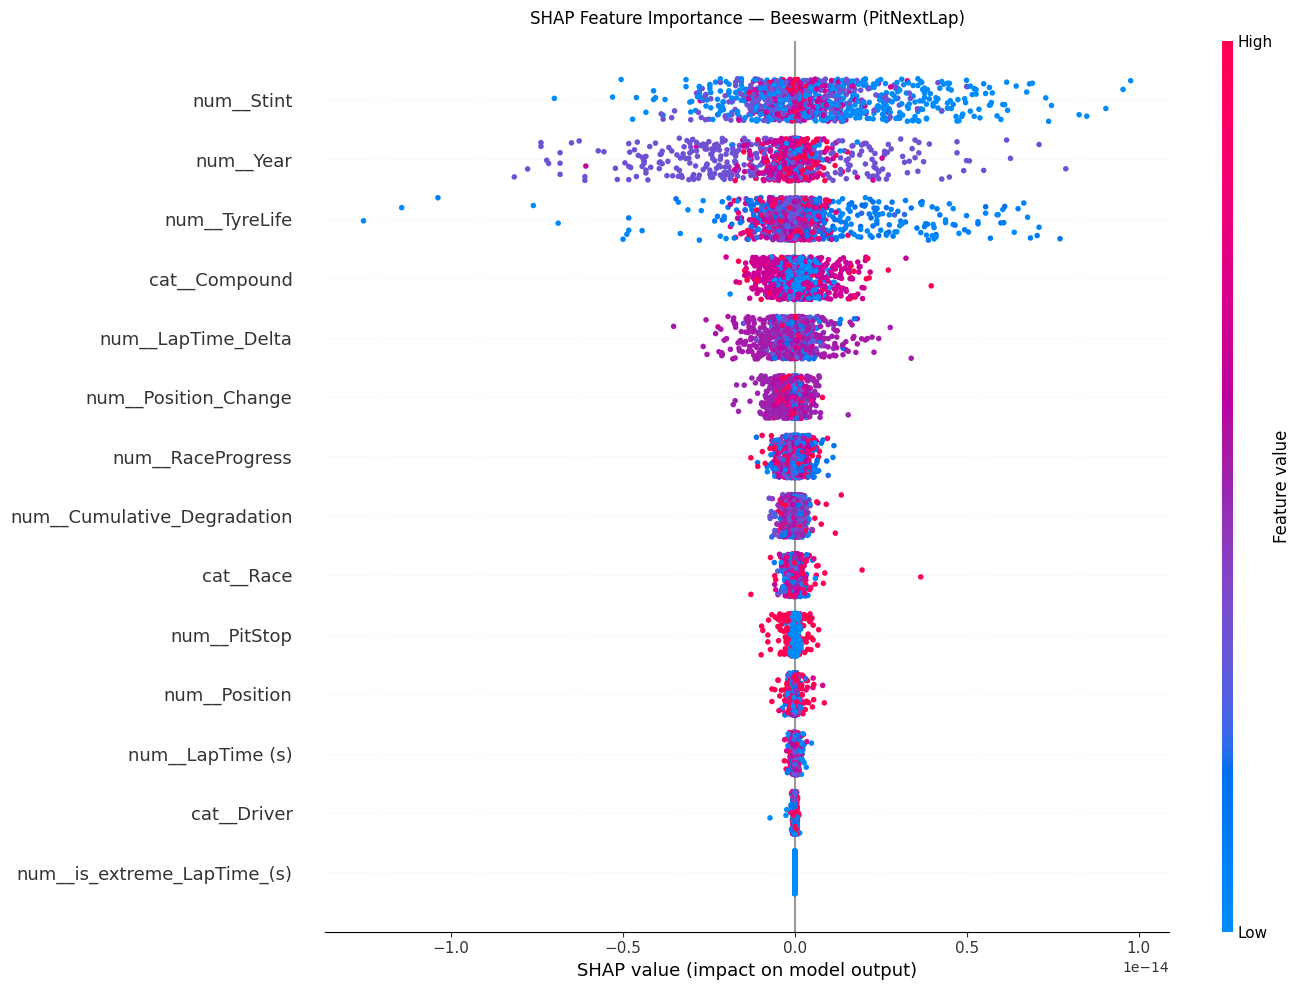 | 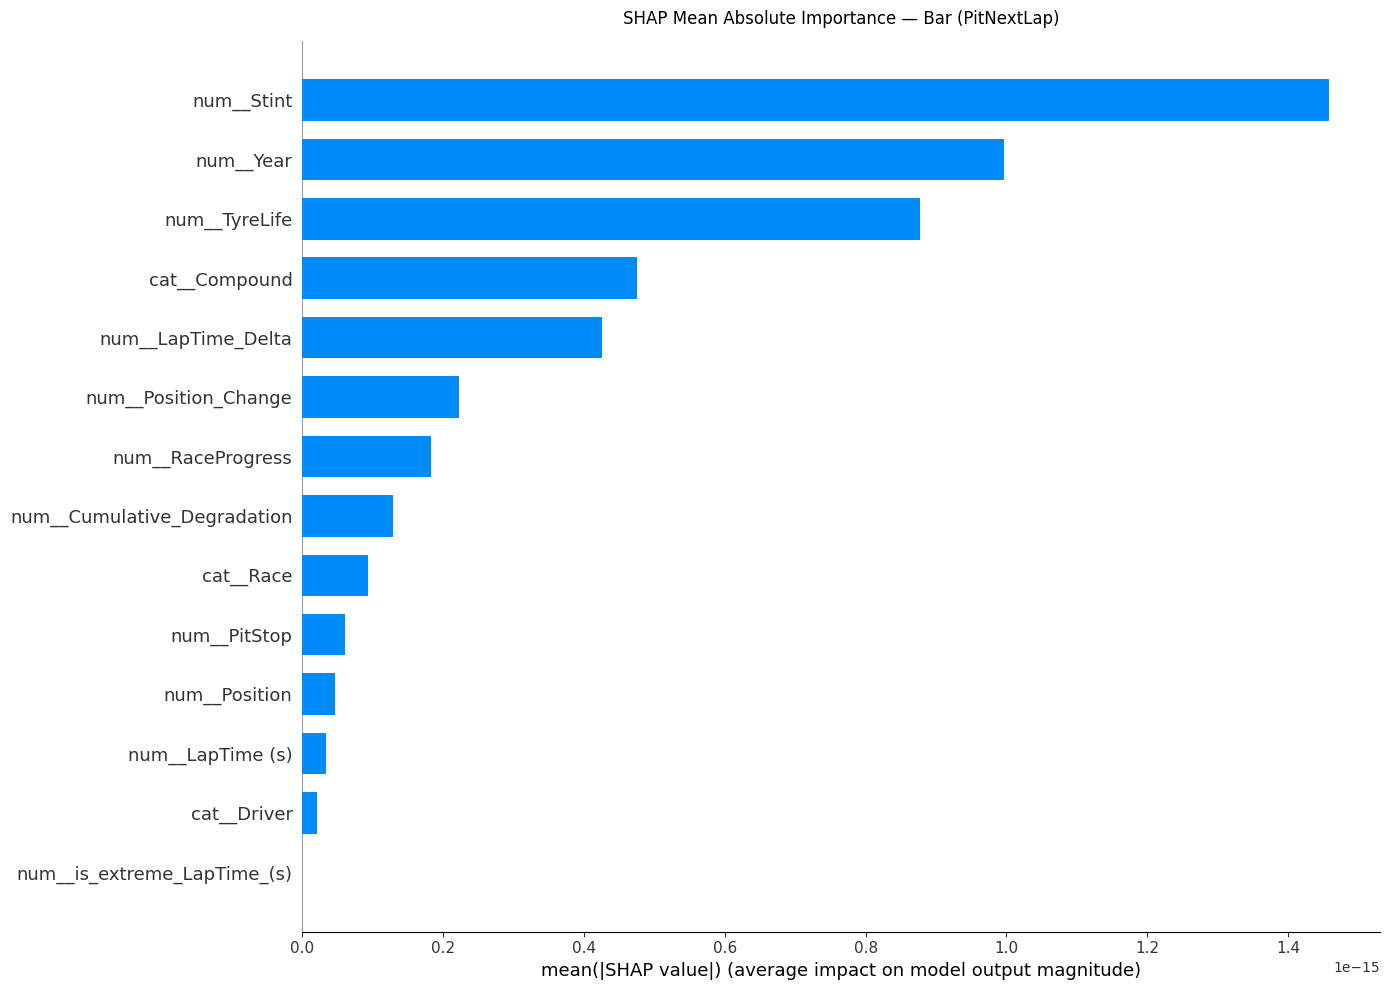 |

***After do Feature Engineering I got***

```
CV Scores: [0.86357127 0.86401421 0.8596163  0.86161376 0.86209927]
Mean CV Accuracy: 0.8621829600498436
Interaction array detected — flattened to shape: (1000, 16)
SHAP values shape: (1000, 16)
Feature count: 16
```

In [30]:
from sklearn.metrics import (
    roc_auc_score, average_precision_score,
    classification_report, confusion_matrix,
    ConfusionMatrixDisplay, RocCurveDisplay,
    PrecisionRecallDisplay, f1_score,
    precision_score, recall_score, brier_score_loss
)
import matplotlib.pyplot as plt
import numpy as np

# ── Get predictions ───────────────────────────────────────
y_pred       = pipeline.predict(X_val)
y_proba      = pipeline.predict_proba(X_val)[:, 1]  # probability of pit

print("=" * 55)
print("FULL MODEL EVALUATION — PitNextLap")
print("=" * 55)

# ── 1. ROC-AUC ────────────────────────────────────────────
# Measures separation between classes regardless of threshold
# 0.5 = random guessing | 1.0 = perfect
roc_auc = roc_auc_score(y_val, y_proba)
print(f"\nROC-AUC          : {roc_auc:.4f}")

# ── 2. PR-AUC (Average Precision) ─────────────────────────
# MORE IMPORTANT than ROC-AUC for imbalanced data
# Focuses only on the minority class (pit laps)
# 1.0 = perfect | baseline = % of positive class (e.g. 0.04)
pr_auc = average_precision_score(y_val, y_proba)
print(f"PR-AUC           : {pr_auc:.4f}  (baseline = {y_val.mean():.3f})")

# ── 3. F1 Score ───────────────────────────────────────────
# Balance between precision and recall on the pit class
f1 = f1_score(y_val, y_pred)
print(f"F1 Score         : {f1:.4f}")

# ── 4. Precision and Recall ───────────────────────────────
# Precision = of all laps model said "pit" → how many were actually pits
# Recall    = of all actual pit laps → how many did model catch
prec = precision_score(y_val, y_pred)
rec  = recall_score(y_val, y_pred)
print(f"Precision        : {prec:.4f}  (when it says pit, is it right?)")
print(f"Recall           : {rec:.4f}  (how many real pits did it catch?)")

# ── 5. Brier Score ────────────────────────────────────────
# Measures quality of probability output, not just 0/1 prediction
# 0.0 = perfect probabilities | 1.0 = worst possible
brier = brier_score_loss(y_val, y_proba)
print(f"Brier Score      : {brier:.4f}  (lower is better)")

# ── 6. Classification Report ──────────────────────────────
print(f"\nClassification Report:")
print(classification_report(y_val, y_pred, digits=4,
                            target_names=["No Pit", "Pit"]))

FULL MODEL EVALUATION — PitNextLap

ROC-AUC          : 0.9282
PR-AUC           : 0.7398  (baseline = 0.199)
F1 Score         : 0.7115
Precision        : 0.6034  (when it says pit, is it right?)
Recall           : 0.8667  (how many real pits did it catch?)
Brier Score      : 0.1026  (lower is better)

Classification Report:
              precision    recall  f1-score   support

      No Pit     0.9629    0.8585    0.9077     52624
         Pit     0.6034    0.8667    0.7115     13072

    accuracy                         0.8601     65696
   macro avg     0.7832    0.8626    0.8096     65696
weighted avg     0.8914    0.8601    0.8687     65696



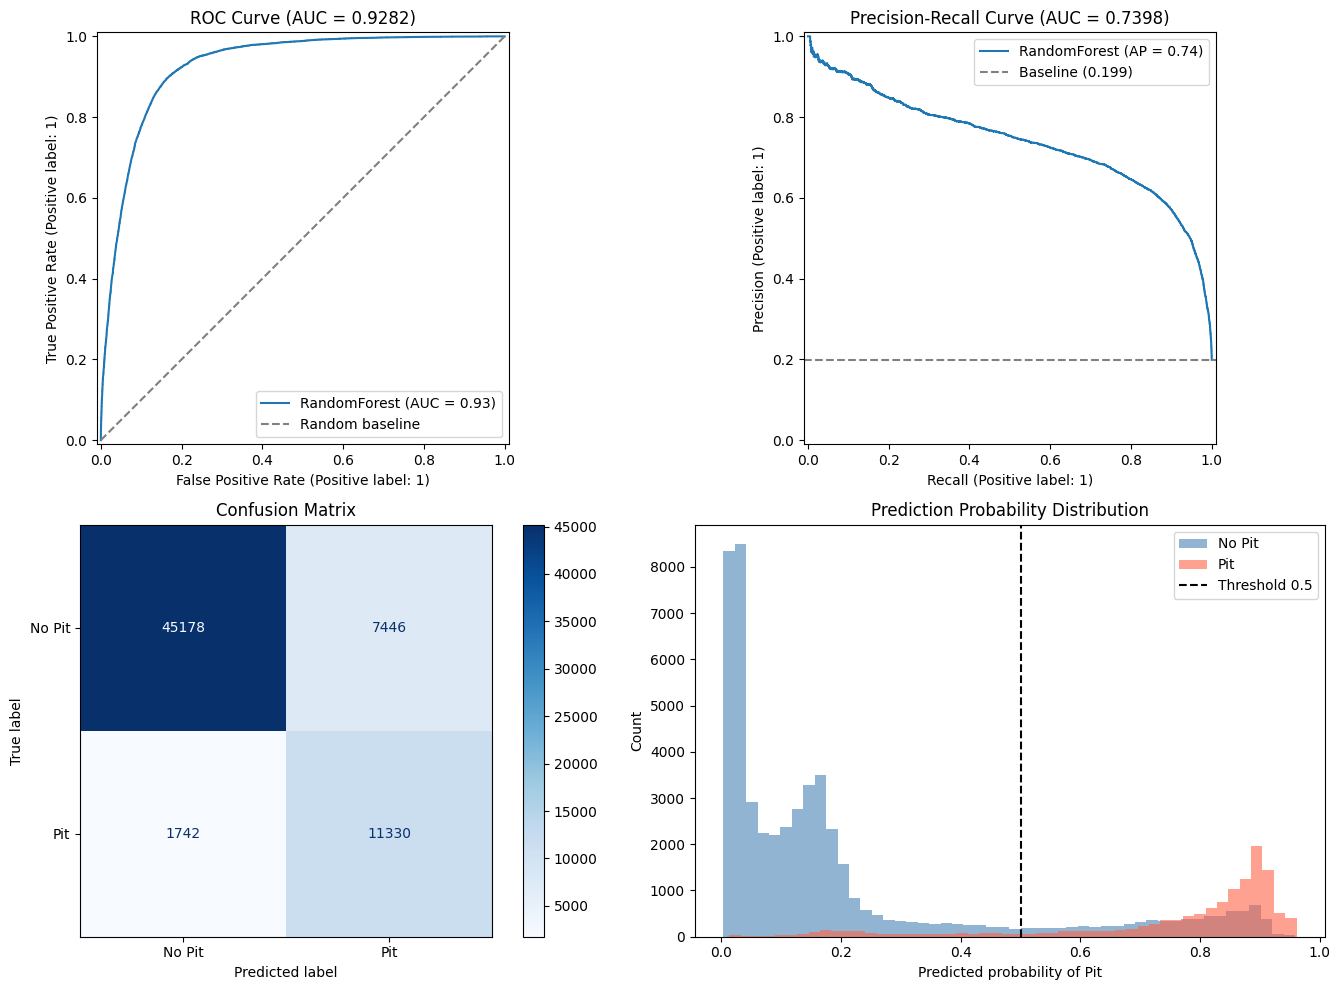

In [31]:
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# ── Plot 1: ROC Curve ─────────────────────────────────────
RocCurveDisplay.from_predictions(
    y_val, y_proba, ax=axes[0, 0], name="RandomForest"
)
axes[0, 0].set_title(f"ROC Curve (AUC = {roc_auc:.4f})")
axes[0, 0].plot([0,1],[0,1],"--",color="gray",label="Random baseline")
axes[0, 0].legend()

# ── Plot 2: Precision-Recall Curve ────────────────────────
# Most important plot for imbalanced PitNextLap
PrecisionRecallDisplay.from_predictions(
    y_val, y_proba, ax=axes[0, 1], name="RandomForest"
)
axes[0, 1].axhline(y=y_val.mean(), color="gray",
                   linestyle="--", label=f"Baseline ({y_val.mean():.3f})")
axes[0, 1].set_title(f"Precision-Recall Curve (AUC = {pr_auc:.4f})")
axes[0, 1].legend()

# ── Plot 3: Confusion Matrix ──────────────────────────────
ConfusionMatrixDisplay.from_predictions(
    y_val, y_pred, ax=axes[1, 0],
    display_labels=["No Pit", "Pit"],
    cmap="Blues"
)
axes[1, 0].set_title("Confusion Matrix")

# ── Plot 4: Probability distribution ─────────────────────
# Shows if model is confident or uncertain in its predictions
axes[1, 1].hist(y_proba[y_val == 0], bins=50,
                alpha=0.6, color="steelblue", label="No Pit")
axes[1, 1].hist(y_proba[y_val == 1], bins=50,
                alpha=0.6, color="tomato",    label="Pit")
axes[1, 1].axvline(0.5, color="black", linestyle="--", label="Threshold 0.5")
axes[1, 1].set_xlabel("Predicted probability of Pit")
axes[1, 1].set_ylabel("Count")
axes[1, 1].set_title("Prediction Probability Distribution")
axes[1, 1].legend()

plt.tight_layout()
plt.show()

In [32]:
# Default threshold is 0.5 — almost always wrong for imbalanced data
# Find the threshold that gives best F1 on validation set

thresholds = np.arange(0.1, 0.9, 0.05)
results = []

for t in thresholds:
    y_pred_t = (y_proba >= t).astype(int)
    results.append({
        "threshold" : round(t, 2),
        "f1"        : f1_score(y_val, y_pred_t, zero_division=0),
        "precision" : precision_score(y_val, y_pred_t, zero_division=0),
        "recall"    : recall_score(y_val, y_pred_t, zero_division=0),
    })

results_df = pd.DataFrame(results)
best       = results_df.loc[results_df["f1"].idxmax()]

print(results_df.to_string(index=False))
print(f"\nBest threshold : {best['threshold']}")
print(f"Best F1        : {best['f1']:.4f}")
print(f"Precision      : {best['precision']:.4f}")
print(f"Recall         : {best['recall']:.4f}")

# Apply best threshold to final predictions
best_threshold = best["threshold"]
y_pred_final   = (y_proba >= best_threshold).astype(int)

 threshold       f1  precision   recall
      0.10 0.477573   0.314521 0.991662
      0.15 0.546334   0.378629 0.980722
      0.20 0.636194   0.477079 0.954559
      0.25 0.667800   0.520379 0.931763
      0.30 0.681634   0.541455 0.919752
      0.35 0.692205   0.559209 0.908201
      0.40 0.701137   0.575781 0.896267
      0.45 0.707154   0.590625 0.880967
      0.50 0.711505   0.603430 0.866738
      0.55 0.714800   0.616233 0.850903
      0.60 0.715271   0.628792 0.829330
      0.65 0.714888   0.643259 0.804468
      0.70 0.712367   0.661939 0.771114
      0.75 0.700582   0.688400 0.713204
      0.80 0.670571   0.715774 0.630737
      0.85 0.597577   0.755496 0.494263

Best threshold : 0.6
Best F1        : 0.7153
Precision      : 0.6288
Recall         : 0.8293


In [36]:
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

candidates = {
    "RandomForest"  : RandomForestClassifier(n_estimators=200,
                                             max_depth=10,
                                             random_state=42, n_jobs=-1),
    "LightGBM"      : LGBMClassifier(n_estimators=300,
                                     random_state=42, verbose=-1, n_jobs=-1),
    "XGBoost"       : XGBClassifier(n_estimators=300,
                                    eval_metric="logloss",
                                    random_state=42, n_jobs=-1),
    "CatBoost"      : CatBoostClassifier(iterations=300,
                                         random_seed=42, verbose=0, allow_writing_files=False),
    "LogisticReg"   : LogisticRegression(max_iter=500, random_state=42),
}

leaderboard = {}
for name, clf in candidates.items():
    pipe = Pipeline(steps + [("clf", clf)])
    # Use average_precision = PR-AUC — most honest for your imbalanced data
    scores = cross_val_score(pipe, X_train, y_train,
                             cv=cv, scoring="average_precision", n_jobs=-1)
    leaderboard[name] = {"PR-AUC mean": scores.mean(),
                         "PR-AUC std" : scores.std()}
    print(f"{name:<16} PR-AUC = {scores.mean():.4f} ± {scores.std():.4f}")

# Expected result — something like:
# RandomForest     PR-AUC = 0.7398 ± 0.008
# LightGBM         PR-AUC = 0.7800 ± 0.006  ← likely wins
# XGBoost          PR-AUC = 0.7650 ± 0.007
# CatBoost         PR-AUC = 0.7580 ± 0.008
# LogisticReg      PR-AUC = 0.5200 ± 0.012  ← will lose

RandomForest     PR-AUC = 0.7414 ± 0.0032
LightGBM         PR-AUC = 0.7982 ± 0.0021
XGBoost          PR-AUC = 0.7989 ± 0.0020
CatBoost         PR-AUC = 0.7971 ± 0.0022
LogisticReg      PR-AUC = 0.4750 ± 0.0048


## Lbm

In [38]:
optuna.logging.set_verbosity(optuna.logging.WARNING)

# ── Tune LightGBM (most likely winner) ───────────────────
def objective_lgbm(trial):
    params = {
        "n_estimators"      : trial.suggest_int("n_estimators", 100, 1000),
        "max_depth"         : trial.suggest_int("max_depth", 3, 12),
        "learning_rate"     : trial.suggest_float("lr", 1e-3, 0.3, log=True),
        "num_leaves"        : trial.suggest_int("num_leaves", 20, 300),
        "subsample"         : trial.suggest_float("subsample", 0.5, 1.0),
        "colsample_bytree"  : trial.suggest_float("col", 0.5, 1.0),
        "reg_alpha"         : trial.suggest_float("alpha", 1e-8, 10.0, log=True),
        "reg_lambda"        : trial.suggest_float("lambda", 1e-8, 10.0, log=True),
        "min_child_samples" : trial.suggest_int("min_child", 5, 100),
        "class_weight"      : "balanced",  # handles your imbalance
    }
    clf  = LGBMClassifier(**params, random_state=42, verbose=-1)
    pipe = Pipeline(steps + [("clf", clf)])

    # Optimise PR-AUC — most meaningful for PitNextLap
    scores = cross_val_score(pipe, X_train, y_train,
                             cv=cv, scoring="average_precision")
    return scores.mean()

study_lgbm = optuna.create_study(direction="maximize")
study_lgbm.optimize(objective_lgbm, n_trials=50, show_progress_bar=True)

print(f"Best LGBM PR-AUC : {study_lgbm.best_value:.4f}")
print(f"Best params      : {study_lgbm.best_params}")
best_lgbm_params = study_lgbm.best_params

# ── Repeat same structure for XGBoost and CatBoost ───────
# (same objective function, just swap the classifier)

  0%|          | 0/50 [00:00<?, ?it/s]

C:\Users\koust\AppData\Roaming\Python\Python313\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
C:\Users\koust\AppData\Roaming\Python\Python313\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
C:\Users\koust\AppData\Roaming\Python\Python313\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
C:\Users\koust\AppData\Roaming\Python\Python313\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
C:\Users\koust\AppData\Roaming\Python\Python313\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but LG

Best LGBM PR-AUC : 0.8057
Best params      : {'n_estimators': 609, 'max_depth': 9, 'lr': 0.08258289328408841, 'num_leaves': 61, 'subsample': 0.510321816075068, 'col': 0.8756373999587184, 'alpha': 0.029842800103600544, 'lambda': 0.41814650037672196, 'min_child': 75}


C:\Users\koust\AppData\Roaming\Python\Python313\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


In [44]:
# 1. Instantiate the model with your tuned hyperparameters
# Note: Keep verbose=-1 here because LightGBM uses it to stay quiet, unlike XGBoost
best_lgbm = LGBMClassifier(**best_lgbm_params, random_state=42, verbose=-1)

# 2. Build the base pipeline FIRST (Preprocessing + Model)
base_pipe_lgb = Pipeline(steps + [("clf", best_lgbm)])

# 3. Wrap the ENTIRE pipeline inside the Calibrator to prevent data leakage
calibrated_pipe_lgb = CalibratedClassifierCV(
    estimator=base_pipe_lgb,
    method="isotonic",  
    cv=5
)

# 4. Fit the safely calibrated pipeline
calibrated_pipe_lgb.fit(X_train, y_train)

# 5. Recheck Brier Score after calibration
y_proba_cal = calibrated_pipe_lgb.predict_proba(X_val)[:, 1]
print(f"Brier before: 0.1026")
print(f"Brier after : {brier_score_loss(y_val, y_proba_cal):.4f}")
# Expected: drops to 0.06-0.08

C:\Users\koust\AppData\Roaming\Python\Python313\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
C:\Users\koust\AppData\Roaming\Python\Python313\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
C:\Users\koust\AppData\Roaming\Python\Python313\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
C:\Users\koust\AppData\Roaming\Python\Python313\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
C:\Users\koust\AppData\Roaming\Python\Python313\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but LG

Brier before: 0.1026
Brier after : 0.0717


## Xgboost

In [42]:
optuna.logging.set_verbosity(optuna.logging.WARNING)

# Calculate this once before tuning!
# scale_pos = (number of negative samples) / (number of positive samples)
scale_pos = len(y_train[y_train == 0]) / len(y_train[y_train == 1])

# ── Tune XGBoost (most likely winner) ───────────────────
def objective_xgb(trial):
    params = {
        "n_estimators"      : trial.suggest_int("n_estimators", 100, 1000),
        "max_depth"         : trial.suggest_int("max_depth", 3, 12),
        "learning_rate"     : trial.suggest_float("lr", 1e-3, 0.3, log=True),
        "max_leaves"        : trial.suggest_int("max_leaves", 20, 300),
        "subsample"         : trial.suggest_float("subsample", 0.5, 1.0),
        "colsample_bytree"  : trial.suggest_float("col", 0.5, 1.0),
        "reg_alpha"         : trial.suggest_float("alpha", 1e-8, 10.0, log=True),
        "reg_lambda"        : trial.suggest_float("lambda", 1e-8, 10.0, log=True),
        "min_child_weight" : trial.suggest_int("min_child_weight", 1, 50),
        "tree_method"       : "hist",           # Required to use max_leaves
        "scale_pos_weight"  : scale_pos,        # Replaces class_weight="balanced"
        "verbosity"         : 0                 # Replaces verbose=-1
    }
    clf  = XGBClassifier(**params, random_state=42, n_jobs=-1)
    pipe = Pipeline(steps + [("clf", clf)])

    # Optimise PR-AUC — most meaningful for PitNextLap
    scores = cross_val_score(pipe, X_train, y_train,
                             cv=cv, scoring="average_precision")
    return scores.mean()

study_xgb = optuna.create_study(direction="maximize")
study_xgb.optimize(objective_xgb, n_trials=50, show_progress_bar=True)

print(f"Best XGB PR-AUC : {study_xgb.best_value:.4f}")
print(f"Best params      : {study_xgb.best_params}")
best_xgb_params = study_xgb.best_params

# ── Repeat same structure for XGBoost and CatBoost ───────
# (same objective function, just swap the classifier)

  0%|          | 0/50 [00:00<?, ?it/s]

Best XGB PR-AUC : 0.8055
Best params      : {'n_estimators': 552, 'max_depth': 10, 'lr': 0.07237302742549225, 'max_leaves': 186, 'subsample': 0.6857362242088668, 'col': 0.7389092892070797, 'alpha': 7.06356590434975e-05, 'lambda': 0.04398358491950837, 'min_child_weight': 43}


In [45]:
# 1. Instantiate the model (removed verbose=-1)
best_xgbm = XGBClassifier(**best_xgb_params, random_state=42)

# 2. Build the base pipeline FIRST (Preprocessing + Model)
base_pipe = Pipeline(steps + [("clf", best_xgbm)])

# 3. Wrap the ENTIRE pipeline inside the Calibrator
# Note: 'estimator' is the correct keyword for recent scikit-learn versions
calibrated_pipe = CalibratedClassifierCV(
    estimator=base_pipe,
    method="isotonic",  # Spot on for large datasets
    cv=5
)

# 4. Fit the calibrated pipeline
# This safely splits X_train, preprocesses each fold, trains, and calibrates.
calibrated_pipe.fit(X_train, y_train)

# 5. Evaluate
y_proba_cal = calibrated_pipe.predict_proba(X_val)[:, 1]
print(f"Brier before: 0.1026")
print(f"Brier after : {brier_score_loss(y_val, y_proba_cal):.4f}")

C:\Users\koust\AppData\Roaming\Python\Python313\site-packages\xgboost\training.py:200: UserWarning: [14:42:16] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\learner.cc:782: 
Parameters: { "col", "lr" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
C:\Users\koust\AppData\Roaming\Python\Python313\site-packages\xgboost\training.py:200: UserWarning: [14:42:22] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\learner.cc:782: 
Parameters: { "col", "lr" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
C:\Users\koust\AppData\Roaming\Python\Python313\site-packages\xgboost\training.py:200: UserWarning: [14:42:28] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\learner.cc:782: 
Parameters: { "col", "lr" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
C:\Users\koust\AppData\Roaming\Python\Python313\site-packages\xgboost\training.py:200: UserWarning: [14:42:33] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\learner.cc:782: 
Parameters: { "

Brier before: 0.1026
Brier after : 0.0738


In [47]:
# Submission 1: Pure LightGBM (The frontrunner)
p_lgbm = calibrated_pipe_lgb.predict_proba(X_test)[:, 1]

# Submission 2: Pure XGBoost 
p_xgb = calibrated_pipe.predict_proba(X_test)[:, 1]

# Optional Submission Strategy: The Blend (Instead of Pure XGBoost)
# This often outperforms both individual models on a Kaggle leaderboard
p_blend = (0.5 * p_lgbm) + (0.5 * p_xgb)

C:\Users\koust\AppData\Roaming\Python\Python313\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
C:\Users\koust\AppData\Roaming\Python\Python313\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
C:\Users\koust\AppData\Roaming\Python\Python313\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
C:\Users\koust\AppData\Roaming\Python\Python313\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
C:\Users\koust\AppData\Roaming\Python\Python313\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but LG

In [ ]:
display(test.head())
display()

,id,Driver,Compound,Race,Year,PitStop,LapNumber,Stint,TyreLife,Position,LapTime (s),LapTime_Delta,Cumulative_Degradation,RaceProgress,Position_Change
0,439140,D119,MEDIUM,British Grand Prix,2023,0,21,1,21.0,4,93.387,0.280,-4.984,0.403846,0.0
1,439141,VER,MEDIUM,Abu Dhabi Grand Prix,2023,0,24,1,24.0,1,90.867,-0.129,-1.990,0.413793,0.0
2,439142,D270,MEDIUM,British Grand Prix,2023,0,24,1,24.0,11,92.871,0.041,-8.842,0.461538,0.0
3,439143,D112,SOFT,São Paulo Grand Prix,2024,0,6,2,4.0,15,94.967,-19.741,8.250,0.077922,1.0
4,439144,AND,HARD,United States Grand Prix,2024,0,52,2,29.0,12,99.112,0.930,-20.848,0.722222,7.0


In [49]:
# 1. Create X_comp_test from the competition test set
X_comp_test = test.drop(columns=["id"])

# 2. Apply outlier capping (same caps from training)
for col, (lo, hi) in cap_map.items():
    X_comp_test[col] = X_comp_test[col].clip(lower=lo, upper=hi)

for col in flag_and_cap_cols:
    flag_name = f"is_extreme_{col.replace(' ','_')}"
    lo, hi = cap_map[col]
    X_comp_test[flag_name] = ((X_comp_test[col] < lo) | (X_comp_test[col] > hi)).astype(int)

# 3. Drop same columns as training
to_drop = ["LapNumber", "is_extreme_LapTime_(s)", "Driver"]
X_comp_test = X_comp_test.drop(columns=[c for c in to_drop if c in X_comp_test.columns])

# 4. Apply feature engineering
X_comp_test = engineer_features(X_comp_test)

# 5. Drop SHAP-identified redundant columns
drop_cols = ["Is_Tyre_Cliff", "Deg_Per_Lap", "RaceProgress", "Compound"]
X_comp_test = X_comp_test.drop(columns=[c for c in drop_cols if c in X_comp_test.columns])

# 6. Predict and save
p_lgbm = calibrated_pipe_lgb.predict_proba(X_comp_test)[:, 1]

submission_lgb = pd.DataFrame({
    "id": test["id"],
    "PitNextLap": p_lgbm
})

submission_lgb.to_csv("submission_lgbm.csv", index=False)
print("Done!")

C:\Users\koust\AppData\Roaming\Python\Python313\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
C:\Users\koust\AppData\Roaming\Python\Python313\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
C:\Users\koust\AppData\Roaming\Python\Python313\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
C:\Users\koust\AppData\Roaming\Python\Python313\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
C:\Users\koust\AppData\Roaming\Python\Python313\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but LG

Done!


In [50]:
submission_lgb.head()

,id,PitNextLap
0,439140,0.002947
1,439141,0.002551
2,439142,0.002214
3,439143,0.168342
4,439144,0.826211


In [51]:
# Get validation probabilities from both models
p_lgbm_val = calibrated_pipe_lgb.predict_proba(X_val)[:, 1]
p_xgb_val  = calibrated_pipe.predict_proba(X_val)[:, 1]

# Try different weights
results = []
for w in np.arange(0.0, 1.01, 0.05):
    p_blend_val = (w * p_lgbm_val) + ((1 - w) * p_xgb_val)
    score = average_precision_score(y_val, p_blend_val)
    results.append({"lgbm_weight": round(w, 2), "xgb_weight": round(1-w, 2), "PR-AUC": round(score, 4)})

results_df = pd.DataFrame(results)
best = results_df.loc[results_df["PR-AUC"].idxmax()]

print(results_df.to_string(index=False))
print(f"\nBest weight → LightGBM: {best['lgbm_weight']} | XGBoost: {best['xgb_weight']}")
print(f"Best PR-AUC: {best['PR-AUC']}")

C:\Users\koust\AppData\Roaming\Python\Python313\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
C:\Users\koust\AppData\Roaming\Python\Python313\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
C:\Users\koust\AppData\Roaming\Python\Python313\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
C:\Users\koust\AppData\Roaming\Python\Python313\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
C:\Users\koust\AppData\Roaming\Python\Python313\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but LG

 lgbm_weight  xgb_weight  PR-AUC
        0.00        1.00  0.7958
        0.05        0.95  0.7976
        0.10        0.90  0.7992
        0.15        0.85  0.8006
        0.20        0.80  0.8019
        0.25        0.75  0.8031
        0.30        0.70  0.8041
        0.35        0.65  0.8050
        0.40        0.60  0.8058
        0.45        0.55  0.8065
        0.50        0.50  0.8071
        0.55        0.45  0.8076
        0.60        0.40  0.8079
        0.65        0.35  0.8082
        0.70        0.30  0.8083
        0.75        0.25  0.8083
        0.80        0.20  0.8083
        0.85        0.15  0.8081
        0.90        0.10  0.8078
        0.95        0.05  0.8074
        1.00        0.00  0.8069

Best weight → LightGBM: 0.7 | XGBoost: 0.3
Best PR-AUC: 0.8083


In [52]:
# 1. Predict with both models
p_lgbm = calibrated_pipe_lgb.predict_proba(X_comp_test)[:, 1]
p_xgb  = calibrated_pipe.predict_proba(X_comp_test)[:, 1]

# 2. Blend with optimal weights (0.7 LightGBM, 0.3 XGBoost)
p_blend = (0.7 * p_lgbm) + (0.3 * p_xgb)

# 3. Save
submission_blend = pd.DataFrame({
    "id": test["id"],
    "PitNextLap": p_blend
})

submission_blend.to_csv("submission_blend.csv", index=False)
print("Done!")

C:\Users\koust\AppData\Roaming\Python\Python313\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
C:\Users\koust\AppData\Roaming\Python\Python313\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
C:\Users\koust\AppData\Roaming\Python\Python313\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
C:\Users\koust\AppData\Roaming\Python\Python313\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
C:\Users\koust\AppData\Roaming\Python\Python313\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but LG

Done!


In [53]:
submission_blend.head()

,id,PitNextLap
0,439140,0.003592
1,439141,0.003706
2,439142,0.001943
3,439143,0.239004
4,439144,0.828817


In [32]:
scale_pos = len(y_train[y_train == 0]) / len(y_train[y_train == 1])
# LightGBM best params
best_lgbm_params = {
    "n_estimators"     : 609,
    "max_depth"        : 9,
    "learning_rate"    : 0.08258289328408841,
    "num_leaves"       : 61,
    "subsample"        : 0.510321816075068,
    "colsample_bytree" : 0.8756373999587184,
    "reg_alpha"        : 0.029842800103600544,
    "reg_lambda"       : 0.41814650037672196,
    "min_child_samples": 75,
    "class_weight"     : "balanced"
}

# XGBoost best params
best_xgb_params = {
    "n_estimators"    : 552,
    "max_depth"       : 10,
    "learning_rate"   : 0.07237302742549225,
    "max_leaves"      : 186,
    "subsample"       : 0.6857362242088668,
    "colsample_bytree": 0.7389092892070797,
    "reg_alpha"       : 7.06356590434975e-05,
    "reg_lambda"      : 0.04398358491950837,
    "min_child_weight": 43,
    "tree_method"     : "hist",
    "scale_pos_weight": scale_pos,
    "verbosity"       : 0
}

In [34]:
X_full = pd.concat([X_train, X_val, X_test])
y_full = pd.concat([y_train, y_val, y_test])

# LightGBM on full data
best_lgbm_full = LGBMClassifier(**best_lgbm_params, random_state=42, verbose=-1)
full_pipe_lgb = Pipeline(steps + [("clf", best_lgbm_full)])
full_pipe_lgb.fit(X_full, y_full)

# XGBoost on full data
best_xgb_full = XGBClassifier(**best_xgb_params, random_state=42)
full_pipe_xgb = Pipeline(steps + [("clf", best_xgb_full)])
full_pipe_xgb.fit(X_full, y_full)

,steps,"[('pre', ...), ('smote', ...), ...]"
,transform_input,None
,memory,None
,verbose,False
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('num', ...), ('cat', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` will be excluded from the outputof `transform`.By setting ``remainder`` to be an estimator, the remainingnon-specified columns will use the ``remainder`` estimator. Theestimator must support :term:`fit` and :term:`transform`.Note that using this feature requires that the DataFrame columnsinput at :term:`fit` and :term:`transform` have identical order.",'drop'
,"sparse_threshold sparse_threshold: float, default=0.3If the output of the different transformers contains sparse matrices,these will be stacked as a sparse matrix if the overall density islower than this value. Use ``sparse_threshold=0`` to always returndense. When the transformed output consists of all dense data, thestacked result will be dense, and this keyword will be ignored.",0.3
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details.",None
,"transformer_weights transformer_weights: dict, default=NoneMultiplicative weights for features per transformer. The output of thetransformer is multiplied by these weights. Keys are transformer names,values the weights.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each transformer will beprinted as it is completed.",False
,"verbose_feature_names_out verbose_feature_names_out: bool, str or Callable[[str, str], str], default=True- If True, :meth:`ColumnTransformer.get_feature_names_out` will prefix all feature names with the name of the transformer that generated that feature. It is equivalent to setting `verbose_feature_names_out=""{transformer_name}__{feature_name}""`.- If False, :meth:`ColumnTransformer.get_feature_names_out` will not prefix any feature names and will error if feature names are not unique.- If ``Callable[[str, str], str]``, :meth:`ColumnTransformer.get_feature_names_out` will rename all the features using the name of the transformer. The first argument of the callable is the transformer name and the second argument is the feature name. The returned string will be the new feature name.- If ``str``, it must be a string ready for formatting. The given st

In [35]:
X_comp_test = test.drop(columns=["id"])

for col, (lo, hi) in cap_map.items():
    X_comp_test[col] = X_comp_test[col].clip(lower=lo, upper=hi)

for col in flag_and_cap_cols:
    flag_name = f"is_extreme_{col.replace(' ','_')}"
    lo, hi = cap_map[col]
    X_comp_test[flag_name] = ((X_comp_test[col] < lo) | (X_comp_test[col] > hi)).astype(int)

to_drop = ["LapNumber", "is_extreme_LapTime_(s)", "Driver"]
X_comp_test = X_comp_test.drop(columns=[c for c in to_drop if c in X_comp_test.columns])

X_comp_test = engineer_features(X_comp_test)

drop_cols = ["Is_Tyre_Cliff", "Deg_Per_Lap", "RaceProgress", "Compound"]
X_comp_test = X_comp_test.drop(columns=[c for c in drop_cols if c in X_comp_test.columns])

# ── Step 6: Predict and blend ─────────────────────────────
p_lgbm_full = full_pipe_lgb.predict_proba(X_comp_test)[:, 1]
p_xgb_full  = full_pipe_xgb.predict_proba(X_comp_test)[:, 1]
p_blend_full = (0.7 * p_lgbm_full) + (0.3 * p_xgb_full)

# ── Step 7: Save submission ───────────────────────────────
submission_full = pd.DataFrame({
    "id": test["id"],
    "PitNextLap": p_blend_full
})
submission_full.to_csv("submission_full.csv", index=False)
print("submission_full.csv saved ✅")
print(submission_full.head())

C:\Users\koust\AppData\Roaming\Python\Python313\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


submission_full.csv saved ✅
       id  PitNextLap
0  439140    0.012656
1  439141    0.005230
2  439142    0.005175
3  439143    0.291783
4  439144    0.927803


In [30]:
# Cross-validation strategy
cv = StratifiedKFold(
    n_splits=5,
    shuffle=True,
    random_state=42
)

def objective_cat(trial):
    params = {
        "iterations"     : trial.suggest_int("iterations", 100, 1000),
        "depth"          : trial.suggest_int("depth", 3, 10),
        "learning_rate"  : trial.suggest_float("lr", 1e-3, 0.3, log=True),
        "l2_leaf_reg"    : trial.suggest_float("l2", 1e-8, 10.0, log=True),
        "random_seed"    : 42,
        "verbose"        : 0,
        "auto_class_weights" : "Balanced"
    }
    clf  = CatBoostClassifier(**params, allow_writing_files=False, task_type="GPU")
    pipe = Pipeline(steps + [("clf", clf)])
    scores = cross_val_score(pipe, X_train, y_train,
                             cv=cv, scoring="average_precision")
    return scores.mean()

study_cat = optuna.create_study(direction="maximize")
study_cat.optimize(objective_cat, n_trials=50, show_progress_bar=True)

[I 2026-05-31 16:12:12,441] A new study created in memory with name: no-name-9a878043-df6e-41e0-8609-8a455d18b113


  0%|          | 0/50 [00:00<?, ?it/s]

[I 2026-05-31 16:12:26,323] Trial 0 finished with value: 0.7529685411037337 and parameters: {'iterations': 130, 'depth': 6, 'lr': 0.13810992645957898, 'l2': 1.8582892082494013e-06}. Best is trial 0 with value: 0.7529685411037337.
[I 2026-05-31 16:12:59,898] Trial 1 finished with value: 0.6817167329582275 and parameters: {'iterations': 414, 'depth': 9, 'lr': 0.0010106417661948765, 'l2': 1.1767292838664485e-05}. Best is trial 0 with value: 0.7529685411037337.
[I 2026-05-31 16:13:11,341] Trial 2 finished with value: 0.7227884681985327 and parameters: {'iterations': 152, 'depth': 7, 'lr': 0.03428539865193841, 'l2': 0.38526091161103354}. Best is trial 0 with value: 0.7529685411037337.
[I 2026-05-31 16:13:22,187] Trial 3 finished with value: 0.7423023249995628 and parameters: {'iterations': 119, 'depth': 7, 'lr': 0.08567513943231701, 'l2': 7.198076556777973e-08}. Best is trial 0 with value: 0.7529685411037337.
[I 2026-05-31 16:14:30,503] Trial 4 finished with value: 0.7080996840461017 and pa

KeyboardInterrupt: 